Code Summary:

For our final project, which focuses on breast cancer diagnosis, we will make comparisons between tree-based models (decision tree, random forest, Gradient Boosting, XGBoost), logistic regression, and neural networks. These comparisons will be reflected in our executive summary.

In terms of comparing the predictive performance of these models, **our evaluation metric of interest is recall**, which takes into account false negatives (treating a biopsy as benign when it is actually malignant). While precision (which takes into account false positives - treating a biopsy as malignant when it is actually benign) is important, recall entails life-or-death consequences.   

**Reason for choosing tree-based models:**
Tree-based models like Random Forest can handle non-linear relationships and feature interactions without requiring feature scaling. They are robust to multicollinearity and often perform well on tabular datasets with mixed or redundant features.

**Reason for choosing logistic regression:**
In logistic regression (scaling required), highly correlated independent features (multicollinearity) may disrupt performance. It serves as a simple, interpretable baseline that assumes a linear relationship between the features and the outcome.

**Reason for choosing neural network:**
Neural frameworks (scaling required) are more flexible but require more careful hyperparameter tuning, larger datasets, and come at the cost of reduced interpretability. Given our small sample size, the predictive performance of this model may be limited; however, this NN can learn complex, non-linear patterns in the data and is capable of modeling subtle feature interactions.


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

#Import library for visualising decision tree
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

#import gradient boosting for classification tasks
from xgboost import XGBClassifier

#install libraries for visualization of final decision tree
!apt-get -qq install -y graphviz
!pip install -q graphviz

#building and visualization of neural network
!pip install -U scikit-learn==1.4.2 scikeras tensorflow
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier

upload_file_here = files.upload()

Saving wdbc.data to wdbc.data


In [ ]:
column_names = [
    'ID', 'Diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_standard_error', 'texture_standard_error', 'perimeter_standard_error', 'area_standard_error',
    'smoothness_standard_error', 'compactness_standard_error', 'concavity_standard_error',
    'concave_points_standard_error', 'symmetry_standard_error', 'fractal_dimension_standard_error',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv('wdbc.data', header=None, names=column_names)

X = df.drop(columns=['ID', 'Diagnosis'])
y = df['Diagnosis'].map({'M': 1, 'B': 0})

print(df['Diagnosis'].value_counts(normalize = True))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) #stratification due to skewed proportions

scaler = StandardScaler() #scaling for logistic regression and neural networks
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [ ]:
# Determine best hyperparameters for random forest using gridsearchCV to maximize recall
rfc = RandomForestClassifier(random_state = 42)

param_grid_rfc = {
    'bootstrap': [True],
    'class_weight': [None, 'balanced'],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5],
    'n_estimators': [100, 150]
}

grid_search_rfc = GridSearchCV(
    estimator = rfc, # Assign the RFC instance as the estimator
    param_grid = param_grid_rfc, # Hyperparameter grid for the search
    cv=5, # 5-fold cross validation
    scoring='recall', # Set to prioritize recall
    n_jobs=-1) # Using all available CPU cores

grid_search_rfc.fit(X_train, y_train)
print('Best parameters:', grid_search_rfc.best_params_)

Best parameters: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}



Classification Report:
               precision    recall  f1-score   support

           0    0.96000   1.00000   0.97959        72
           1    1.00000   0.92857   0.96296        42

    accuracy                        0.97368       114
   macro avg    0.98000   0.96429   0.97128       114
weighted avg    0.97474   0.97368   0.97347       114



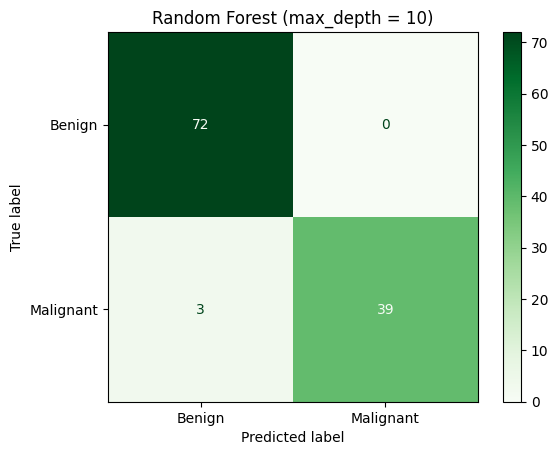

In [ ]:
# Best parameters: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
best_model_rfc = RandomForestClassifier(
    bootstrap=True, # Use bootstrap sampling technique for building trees
    class_weight= None, # No class weighting applied
    max_depth=10, # Limit tree depth to 10
    min_samples_leaf=1, # Minimum samples required at a leaf node
    min_samples_split=2, # Minimum samples required at a split node
    n_estimators=100, # Number of trees in the forest
    random_state=42 # Ensure reproducible results
)

best_model_rfc.fit(X_train, y_train) # Training data trains the model

y_pred_rfc = best_model_rfc.predict(X_test) # Trained model used to make predictions of class labels

print('\nClassification Report:\n', classification_report(y_test, y_pred_rfc, digits = 5))

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=['Benign', 'Malignant'])
disp_rfc.plot(cmap='Greens')
plt.title('Random Forest (max_depth = 10)')
plt.show()

In [ ]:
#Find maximum and mean tree depth and reiterate number of trees in forest
depths = []

for estimator in best_model_rfc.estimators_: # Best_model.estimators returns a list where each element is a trained decision tree
    depth = estimator.tree_.max_depth # Get max depth of the current tree
    depths.append(depth) # Append depth to list

average_depth = np.mean(depths) # Calculate average depth of all trees
max_depth = np.max(depths) # Find maximum tree depth among all trees

print('Number of trees in forest:', len(best_model_rfc.estimators_))
print('Average tree depth:', round(average_depth, 2))
print('Max tree depth:', max_depth)

Number of trees in forest: 100
Average tree depth: 7.19
Max tree depth: 10


In [ ]:
#Determine best decision tree hyperparameters using gridsearchCV to maximize recall
dtc = DecisionTreeClassifier(random_state=42)

param_grid_dtc = {
    'criterion': ['gini', 'entropy'], # Splittint criteria
    'class_weight': [None, 'balanced'],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search_dtc = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid_dtc,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_dtc.fit(X_train, y_train)

print('Best parameters for Decision Tree:', grid_search_dtc.best_params_)

Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}



Classification Report:
               precision    recall  f1-score   support

           0    0.93421   0.98611   0.95946        72
           1    0.97368   0.88095   0.92500        42

    accuracy                        0.94737       114
   macro avg    0.95395   0.93353   0.94223       114
weighted avg    0.94875   0.94737   0.94676       114



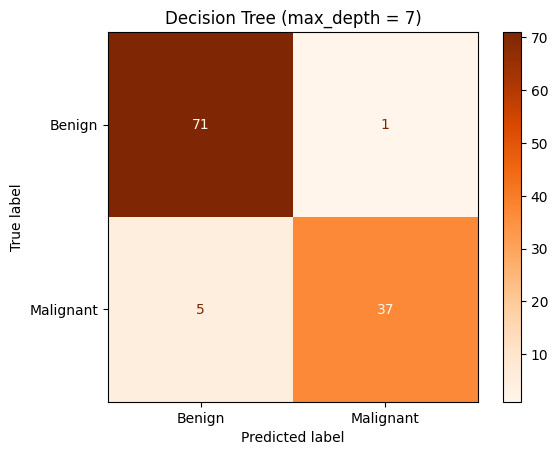

In [ ]:
#Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
best_model_dtc = DecisionTreeClassifier(
    class_weight=None,
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

best_model_dtc.fit(X_train, y_train) # Training data trains the model

y_pred_dtc = best_model_dtc.predict(X_test) # Trained model used to make predictions of class labels

print('\nClassification Report:\n', classification_report(y_test, y_pred_dtc, digits=5))

cm_dtc = confusion_matrix(y_test, y_pred_dtc)
disp_dtc = ConfusionMatrixDisplay(confusion_matrix=cm_dtc, display_labels=['Benign', 'Malignant'])
disp_dtc.plot(cmap='Oranges')
plt.title('Decision Tree (max_depth = 7)')
plt.show()

In [ ]:
print('Maximum decision tree depth:', best_model_dtc.tree_.max_depth)

Maximum decision tree depth: 7


                             Feature  Importance
23                        area_worst    0.151412
27              concave_points_worst    0.126497
20                      radius_worst    0.093475
22                   perimeter_worst    0.083642
7                concave_points_mean    0.081082
2                     perimeter_mean    0.077126
0                        radius_mean    0.061990
6                     concavity_mean    0.050818
3                          area_mean    0.045916
26                   concavity_worst    0.030022
13               area_standard_error    0.029064
25                 compactness_worst    0.018005
21                     texture_worst    0.016174
1                       texture_mean    0.015545
24                  smoothness_worst    0.015093
10             radius_standard_error    0.014503
28                    symmetry_worst    0.013301
5                   compactness_mean    0.012218
12          perimeter_standard_error    0.012037
19  fractal_dimensio

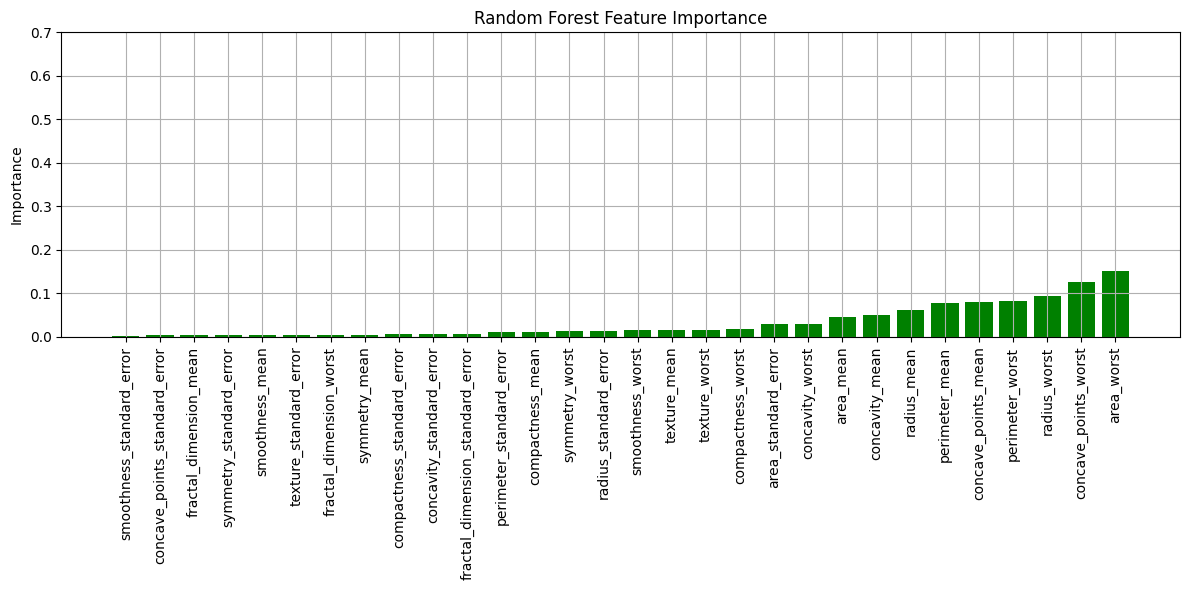

In [ ]:
#importance plot for random forest
importances_rfc = best_model_rfc.feature_importances_ #retrieve importances by feature
feature_names_rfc = X.columns

feature_importance_df_rfc = pd.DataFrame({'Feature': feature_names_rfc, 'Importance': importances_rfc})
feature_importance_df_rfc_sorted = feature_importance_df_rfc.sort_values(by='Importance', ascending=False)

print(feature_importance_df_rfc_sorted)

indices_rfc = np.argsort(importances_rfc) #returns indices of importances sorted from smallest to largest

plt.figure(figsize=(12, 6))
plt.title('Random Forest Feature Importance')
plt.bar(range(len(importances_rfc)), importances_rfc[indices_rfc], color = 'green') #uses indices to retrieve values from array called 'importances'
plt.xticks(range(len(importances_rfc)), feature_names_rfc[indices_rfc], rotation=90)
plt.ylabel('Importance')
plt.ylim(0, 0.7)
plt.yticks(np.arange(0, 0.71, 0.1)) # y-axis increments of 0.1
plt.tight_layout()

plt.grid(True)
plt.show()

                             Feature  Importance
22                   perimeter_worst    0.640385
27              concave_points_worst    0.105853
7                concave_points_mean    0.088994
21                     texture_worst    0.066507
13               area_standard_error    0.045680
15        compactness_standard_error    0.016046
10             radius_standard_error    0.012819
1                       texture_mean    0.012332
17     concave_points_standard_error    0.011383
3                          area_mean    0.000000
5                   compactness_mean    0.000000
4                    smoothness_mean    0.000000
2                     perimeter_mean    0.000000
0                        radius_mean    0.000000
12          perimeter_standard_error    0.000000
11            texture_standard_error    0.000000
8                      symmetry_mean    0.000000
9             fractal_dimension_mean    0.000000
6                     concavity_mean    0.000000
18           symmetr

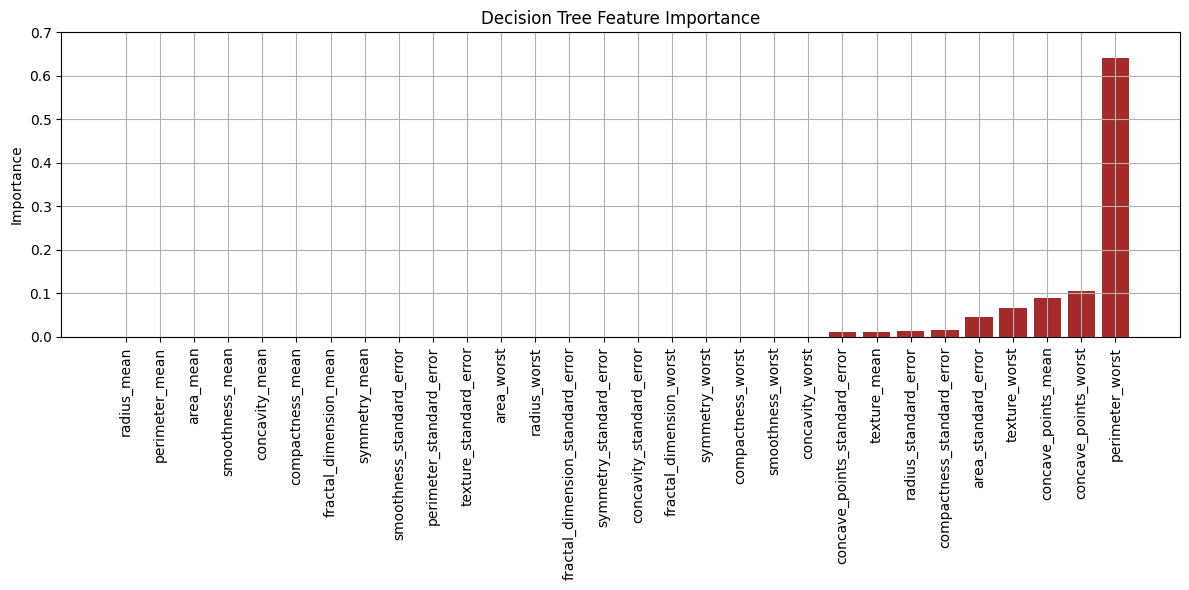

In [ ]:
#importance plot for decision tree
importances_dtc = best_model_dtc.feature_importances_
feature_names_dtc = X.columns

feature_importance_df_dtc = pd.DataFrame({'Feature': feature_names_dtc, 'Importance': importances_dtc})
feature_importance_df_dtc_sorted = feature_importance_df_dtc.sort_values(by='Importance', ascending=False)

print(feature_importance_df_dtc_sorted)

indices_dt = np.argsort(importances_dtc) #indices corresponding to values ordered from smallest to largest

plt.figure(figsize=(12, 6))
plt.title('Decision Tree Feature Importance')
plt.bar(range(len(importances_dtc)), importances_dtc[indices_dt], color = 'brown')
plt.xticks(range(len(importances_dtc)), feature_names_dtc[indices_dt], rotation=90)
plt.ylabel('Importance')
plt.ylim(0, 0.7)
plt.yticks(np.arange(0, 0.71, 0.1))

plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
#validation curves for random forest and decision tree using hyperparameters determined from previous grid searches
param_range = range(1, 13)

#Best parameters: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
rfc_val_curve = RandomForestClassifier(
    bootstrap=True,
    class_weight = None,
    max_depth = 10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators = 100,
    random_state=42
)

#train_scores_rf and test_scores_rf return NumPy arrays of size (12,5)
#accuracy scores when max_depth varies - each row represents a different max_depth, each column corresponds to one of 5 cross-validation folds
train_scores_rf, test_scores_rf = validation_curve(
    estimator = rfc_val_curve,
    X= X_train,
    y= y_train,
    param_name = 'max_depth',
    param_range = param_range,
    cv=5,
    scoring='recall'
)

#Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
dtc_val_curve = DecisionTreeClassifier(
    class_weight = None,
    max_depth = 10,
    criterion='entropy',
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

#array where each element is an accuracy score, each row corresponds to one max_depth, each column corresponds to one cv fold
train_scores_dt, test_scores_dt = validation_curve(
    estimator = dtc_val_curve,
    X= X_train,
    y= y_train,
    param_name='max_depth',
    param_range=param_range,
    cv=5,
    scoring='recall'
)

# axis = 1 means operate across rows
# Training and testing accuracy for each max_depth across 5 cross-validation folds
train_mean_dt = np.mean(train_scores_dt, axis=1)
test_mean_dt = np.mean(test_scores_dt, axis=1)

train_mean_rf = np.mean(train_scores_rf, axis=1)
test_mean_rf = np.mean(test_scores_rf, axis=1)

# Argmax returns index of max value in entire 2D array for testing accuracy
# Index used to access value in range object param_range = range(1,13) - e.g., param_range[5] = 6 since index 5 corresponds to 6th value of 1,2,3,4,5,6
best_max_depth_rf = param_range[np.argmax(test_mean_rf)]
best_max_depth_dt = param_range[np.argmax(test_mean_dt)]

print('Best maximum depth for random forest:', best_max_depth_rf)
print('Best maximum depth for decision tree:', best_max_depth_dt)

Best maximum depth for random forest: 7
Best maximum depth for decision tree: 6


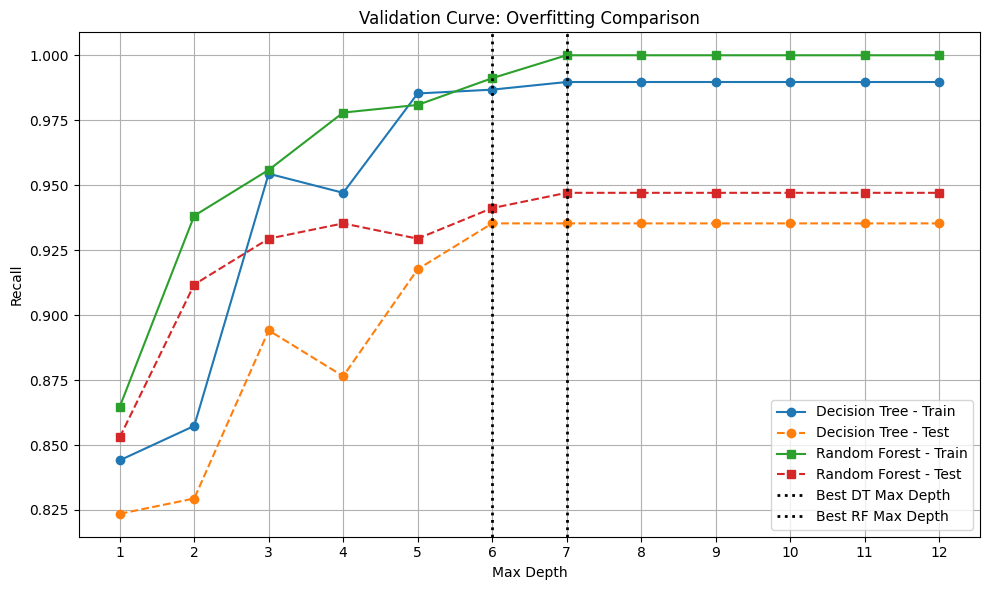

In [ ]:
#validation curves for both models
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean_dt, label='Decision Tree - Train', linestyle='-', marker='o') #circular marker for decision trees
plt.plot(param_range, test_mean_dt, label='Decision Tree - Test', linestyle='--', marker='o')

plt.plot(param_range, train_mean_rf, label='Random Forest - Train', linestyle='-', marker='s') #square marker for random forests
plt.plot(param_range, test_mean_rf, label='Random Forest - Test', linestyle='--', marker='s')

plt.axvline(x=best_max_depth_dt, color='black', linestyle=':', linewidth=2, label='Best DT Max Depth')
plt.axvline(x=best_max_depth_rf, color='black', linestyle=':', linewidth=2, label='Best RF Max Depth')

plt.xlabel('Max Depth')
plt.ylabel('Recall')
plt.title('Validation Curve: Overfitting Comparison')
plt.legend()
plt.grid(True)
plt.xticks(ticks=param_range)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0    0.94737   1.00000   0.97297        72
           1    1.00000   0.90476   0.95000        42

    accuracy                        0.96491       114
   macro avg    0.97368   0.95238   0.96149       114
weighted avg    0.96676   0.96491   0.96451       114



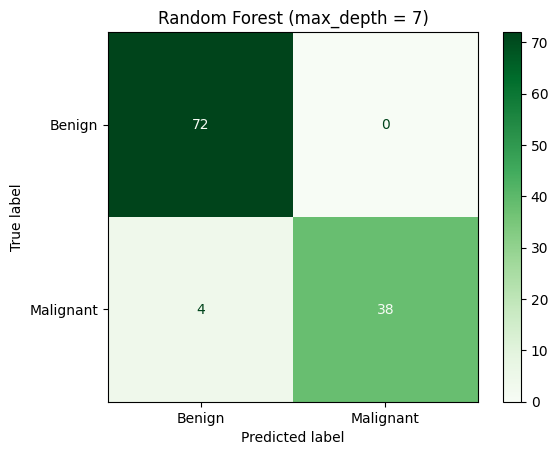

In [ ]:
# Best parameters from random forest grid search: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

# Final random forest using max_depth = 7
vc_model_rfc = RandomForestClassifier(
    bootstrap=False,
    class_weight='balanced',
    max_depth=7,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
)

vc_model_rfc.fit(X_train, y_train) # Training data trains the model

y_pred_rfc = vc_model_rfc.predict(X_test) # Trained model used to make predictions of class labels

print(classification_report(y_test, y_pred_rfc, digits=5))

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
disp_rfc_vc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=['Benign', 'Malignant'])
disp_rfc_vc.plot(cmap='Greens')
plt.title('Random Forest (max_depth = 7)')
plt.show()

              precision    recall  f1-score   support

           0    0.91026   0.98611   0.94667        72
           1    0.97222   0.83333   0.89744        42

    accuracy                        0.92982       114
   macro avg    0.94124   0.90972   0.92205       114
weighted avg    0.93309   0.92982   0.92853       114



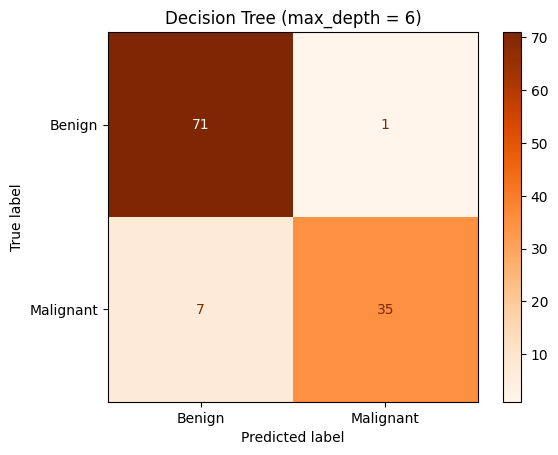

In [ ]:
#Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
#Final decision tree using max_depth = 6
vc_model_dtc = DecisionTreeClassifier(
    class_weight=None,
    criterion='entropy',
    max_depth=6,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

vc_model_dtc.fit(X_train, y_train) #decision tree with max_depth = 6 is trained

y_pred_vc = vc_model_dtc.predict(X_test) #Trained model used to predict class labels

print(classification_report(y_test, y_pred_vc, digits = 5))
cm = confusion_matrix(y_test, y_pred_vc)
disp_dtc_vc = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp_dtc_vc.plot(cmap='Oranges')
plt.title('Decision Tree (max_depth = 6)')
plt.show()

In [ ]:
#Export trained Decision Tree to Graphviz for visualizing feature splits and class outcomes
visual_decisiontree = export_graphviz(
    vc_model_dtc,
    out_file=None,
    feature_names=X.columns,
    class_names=['Benign', 'Malignant'],
    filled=True, # Darker colour indicates greater purity (or lower entropy)
    special_characters=True,
    max_depth=2
)

graph = graphviz.Source(visual_decisiontree)
graph.render('Decision_Tree_Visual', format='png', cleanup=False) # Render and save DT visualization as png without deleting the source file afterwards

files.download('Decision_Tree_Visual.png') # Decision tree visualization with paths

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#tune Gradient Boosting Classifier hyperparameters via GridSearchCV to maximize recall
gbc = GradientBoostingClassifier(random_state=42) #for reproducibility purposes

#same process as random forest and decision tree
param_grid_gbc = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1], # controls the contribution of each tree
    'max_depth': [2, 3, 5],
    'subsample': [0.8, 1.0], # fraction of samples per tree
    'min_samples_leaf': [1, 3]
}

grid_search_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid_gbc,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_gbc.fit(X_train, y_train)
print("Best parameters (Gradient Boosting):", grid_search_gbc.best_params_)

Best parameters (Gradient Boosting): {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 0.8}



Classification Report:
               precision    recall  f1-score   support

           0    0.94737   1.00000   0.97297        72
           1    1.00000   0.90476   0.95000        42

    accuracy                        0.96491       114
   macro avg    0.97368   0.95238   0.96149       114
weighted avg    0.96676   0.96491   0.96451       114



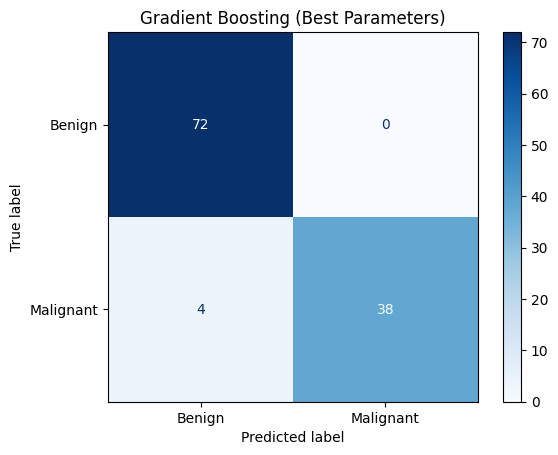

In [ ]:
#best parameters (gradient boosting): {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 0.8}
best_model_gbc = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)

best_model_gbc.fit(X_train, y_train) #trains the model

y_pred_gbc = best_model_gbc.predict(X_test) # Trained model used to make predictions of class labels

print('\nClassification Report:\n', classification_report(y_test, y_pred_gbc, digits=5))

cm_gbc = confusion_matrix(y_test, y_pred_gbc)
disp_gbc = ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=['Benign', 'Malignant'])
disp_gbc.plot(cmap='Blues')
plt.title('Gradient Boosting (Best Parameters)')
plt.show()

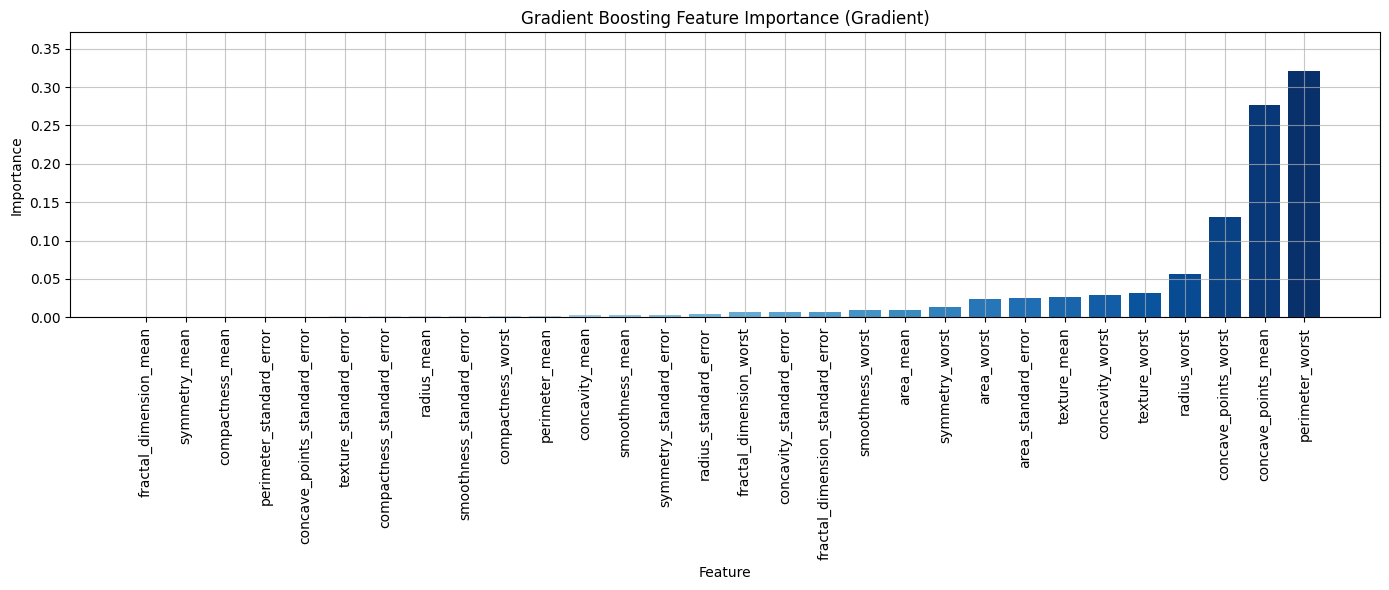

In [ ]:
#gradient boosting feature importances by their contribution to the model
df_gbc = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_gbc.feature_importances_
}).sort_values('Importance', ascending=True)

cmap_gbc = mpl.colormaps['Blues']
colors = cmap_gbc(np.linspace(0, 1, len(df_gbc)))

plt.figure(figsize=(14, 6))
plt.bar(df_gbc['Feature'], df_gbc['Importance'], color=colors)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Gradient Boosting Feature Importance (Gradient)')
plt.xticks(rotation=90)
plt.ylim(0, df_gbc['Importance'].max() + 0.05)
plt.grid(True, axis='y', linestyle='-', alpha=0.7)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#tune XGBoost hyperparameters using GridSearchCV to maximize recall
xgb = XGBClassifier(random_state=42,eval_metric='logloss')

#similar to random forest, decision tree, and gradient boost
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1], #controls step size ; lower values means slow and steady learning
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0], #proportion of training rows randomly sampled for each tree (helps reduce overfitting)
    'colsample_bytree': [0.8], #controls feature sampling per tree
    'gamma': [0, 0.1], #sets minimum loss reduction for further partitioning
    'scale_pos_weight': [1, 2] #balances positive calss weight for imbalanced dataset
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print('Best parameters (XGBoost):', grid_search_xgb.best_params_)

Best parameters (XGBoost): {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'scale_pos_weight': 2, 'subsample': 0.8}



Classification Report:
               precision    recall  f1-score   support

           0    0.95946   0.98611   0.97260        72
           1    0.97500   0.92857   0.95122        42

    accuracy                        0.96491       114
   macro avg    0.96723   0.95734   0.96191       114
weighted avg    0.96518   0.96491   0.96472       114



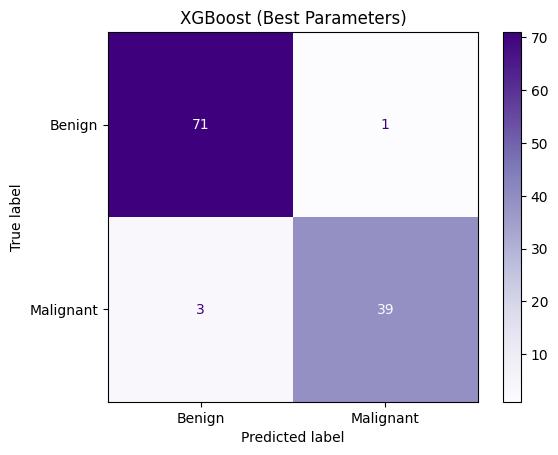

In [ ]:
#best parameters (XGBoost): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'scale_pos_weight': 2, 'subsample': 1.0}
best_model_xgb = XGBClassifier(
    colsample_bytree=0.8,
    gamma=0, #minimum error reduction needed to split a leaf node (end point which holds final prediction)
    learning_rate=0.01, #smaller values mean slow and cautious learning
    max_depth=5,
    n_estimators=50,
    scale_pos_weight=2, #addresses class imbalance
    subsample=1.0, #proportion of training rows used per tree
    random_state=42,
    eval_metric='logloss' #binary classification - penalizes wrong but confident predictions more heavily
)

best_model_xgb.fit(X_train, y_train) # training data trains the model

y_pred_xgb = best_model_xgb.predict(X_test) # trained model used to make predictions of class labels

print('\nClassification Report:\n', classification_report(y_test, y_pred_xgb, digits=5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Benign', 'Malignant'])
disp_xgb.plot(cmap='Purples')
plt.title('XGBoost (Best Parameters)')
plt.show()

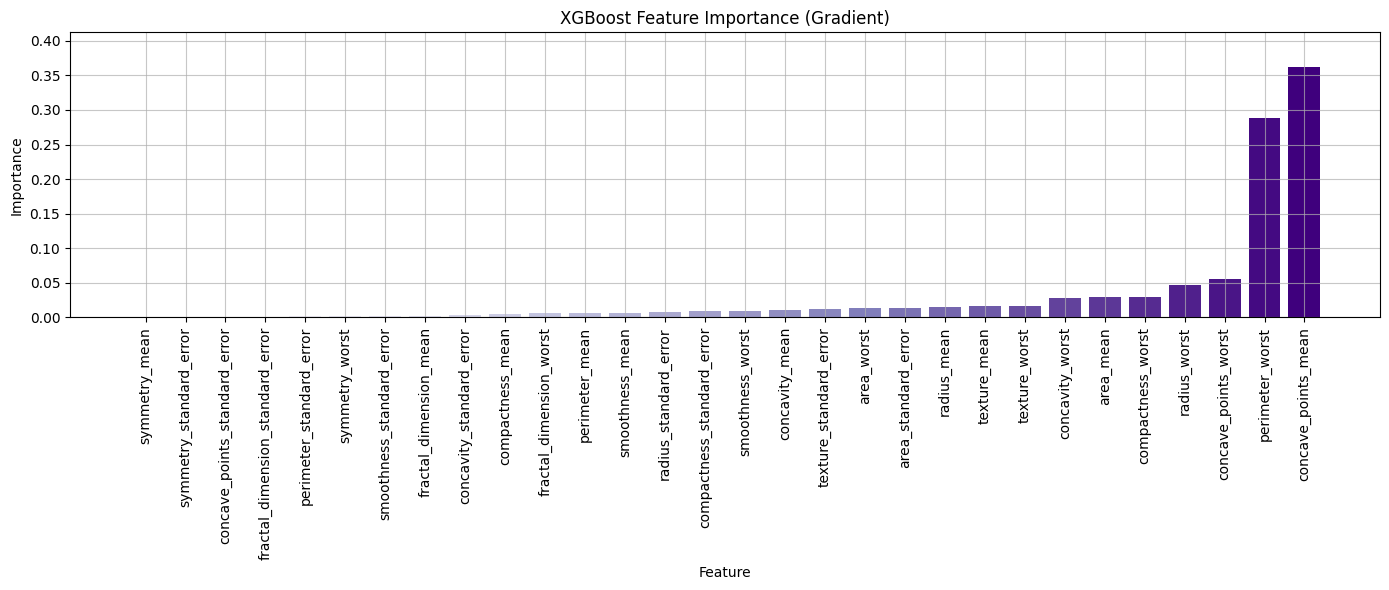

In [ ]:
#XGBoost feature importances by their contribution to the model
df_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

cmap_xgb = mpl.colormaps['Purples']
colors = cmap_xgb(np.linspace(0, 1, len(df_xgb)))


plt.figure(figsize=(14, 6))
plt.bar(df_xgb['Feature'], df_xgb['Importance'], color=colors)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('XGBoost Feature Importance (Gradient)')
plt.xticks(rotation=90)
plt.ylim(0, df_xgb['Importance'].max() + 0.05)
plt.grid(True, axis='y', linestyle='-', alpha=0.7)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#determine best logistic regression hyperparameters using gridsearchCV to maximize recall
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42) # Initialize logistic regression model with increased max iterations for convergence using the lbfgs solver and fixed random state for reproducibility

param_grid_logit = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_search_logit = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_logit,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_logit.fit(X_train_scaled, y_train)
print('Best parameters for Logistic Regression:', grid_search_logit.best_params_)

Best parameters for Logistic Regression: {'C': 0.1, 'class_weight': 'balanced'}



Classification Report:
               precision    recall  f1-score   support

           0    0.98630   1.00000   0.99310        72
           1    1.00000   0.97619   0.98795        42

    accuracy                        0.99123       114
   macro avg    0.99315   0.98810   0.99053       114
weighted avg    0.99135   0.99123   0.99121       114



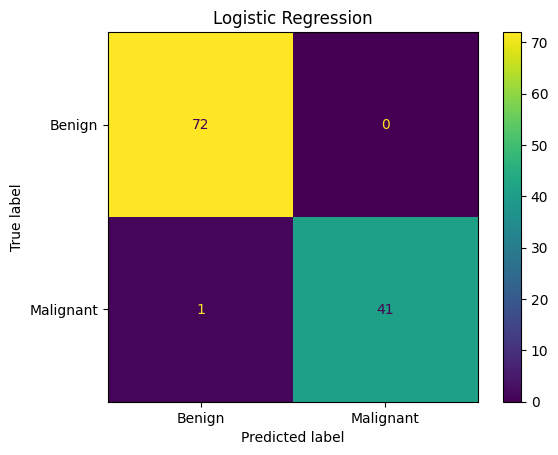

In [ ]:
best_model_logit = LogisticRegression(
    C=0.1, #smaller C value means stronger regularization-> simpler model and less overfitting
    class_weight='balanced', #addresses class imbalance (benign outweighs malignant)
    max_iter=1000, # maximum iterations set to 1000 to ensure model convergence during training
    solver='lbfgs', #memory-efficient optimization algorithm- more chances to chances to optimize weights
    random_state=42
)

best_model_logit.fit(X_train_scaled, y_train) #training data trains the model

y_pred_logit = best_model_logit.predict(X_test_scaled) #trained model used to make predictions of class labels

print('\nClassification Report:\n', classification_report(y_test, y_pred_logit, digits=5))

cm_logit = confusion_matrix(y_test, y_pred_logit)
disp_logit = ConfusionMatrixDisplay(confusion_matrix=cm_logit, display_labels=['Benign', 'Malignant'])
disp_logit.plot()
plt.title('Logistic Regression')
plt.show()

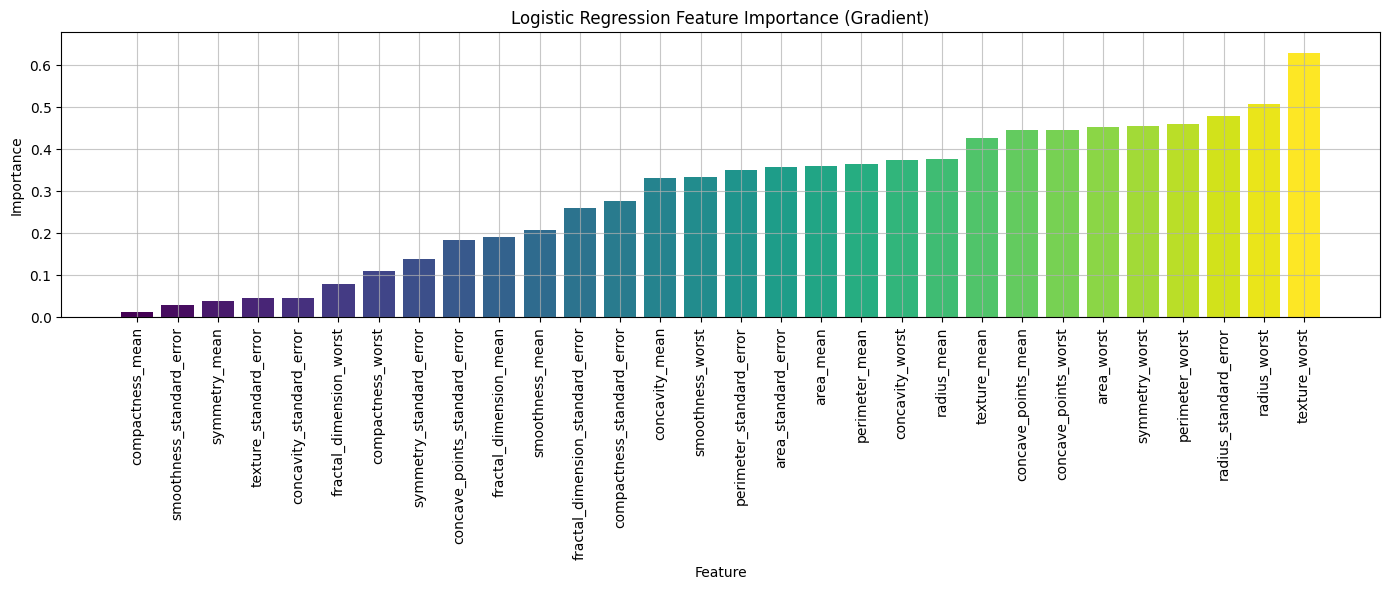

In [ ]:
# Logistic Regression feature importances by absolute coefficient magnitude
df_logit = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(best_model_logit.coef_[0])  # Absolute value of coefficients
}).sort_values('Importance', ascending=True)

# Color mapping
cmap_logit = mpl.colormaps['viridis']
colors = cmap_logit(np.linspace(0, 1, len(df_logit)))

# Plot
plt.figure(figsize=(14, 6))
plt.bar(df_logit['Feature'], df_logit['Importance'], color=colors)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Logistic Regression Feature Importance (Gradient)')
plt.xticks(rotation=90)
plt.ylim(0, df_logit['Importance'].max() + 0.05)
plt.grid(True, axis='y', linestyle='-', alpha=0.7)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#define neural network architecture
def create_model(hidden_layer_sizes=(16,), activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],))) #input layer matching feature count

#add first hidden layer with specified units and activation function
    model.add(Dense(hidden_layer_sizes[0], activation=activation))
#add additional hidden layer
    for units in hidden_layer_sizes[1:]:
        model.add(Dense(units, activation=activation))
#output layer with sigmoid activation for binary classification
    model.add(Dense(1, activation='sigmoid'))

#compile model with binary cross entropy loss, specified optimizer and recall metric
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])
    return model

#suppress verbose output during training
nn_clf = KerasClassifier(model=create_model, verbose=0)

#determine best neural network hyperparameters using gridsearchCV to maximize recall
param_grid_nn = {
    "model__hidden_layer_sizes": [(16,), (32,), (16, 16)],
    "model__activation": ['relu'],
    "model__optimizer": ['adam'],
    "batch_size": [16],
    "epochs": [100]
}

grid_search_nn = GridSearchCV(
    estimator=nn_clf,
    param_grid=param_grid_nn,
    scoring='recall',
    cv=3
)

grid_search_nn.fit(X_train_scaled, y_train)
print("Best parameters for Neural Network:", grid_search_nn.best_params_)

Best parameters for Neural Network: {'batch_size': 16, 'epochs': 100, 'model__activation': 'relu', 'model__hidden_layer_sizes': (16,), 'model__optimizer': 'adam'}


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Classification Report:
               precision    recall  f1-score   support

           0    0.95946   0.98611   0.97260        72
           1    0.97500   0.92857   0.95122        42

    accuracy                        0.96491       114
   macro avg    0.96723   0.95734   0.96191       114
weighted avg    0.96518   0.96491   0.96472       114



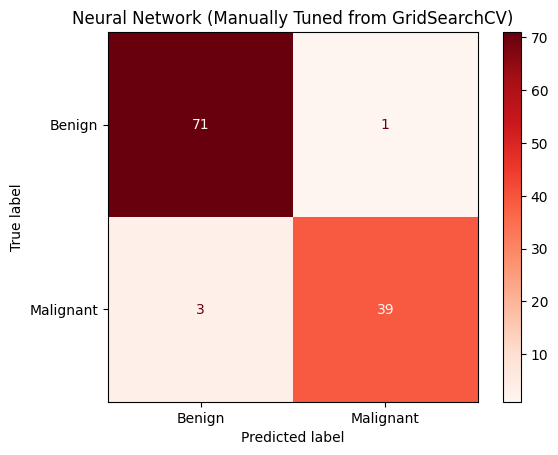

In [ ]:
#create and train neural network
manual_model = Sequential() # Initialize a sequential neural network model
manual_model.add(Input(shape=(X_train_scaled.shape[1],))) #Input layer (30 features)
manual_model.add(Dense(16, activation='relu')) #hidden layer- 16 units - rectified linear unit
manual_model.add(Dense(16, activation='relu')) #hidden layer (also 16 units)
manual_model.add(Dense(1, activation='sigmoid')) #ouput layer - binary classification

manual_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['Recall']) #incorrect predictions penalized with high loss, with recall prioritized

manual_model.fit(X_train_scaled, y_train, batch_size=16, epochs=100, verbose=0) #trains neural network on scaled training data

y_pred_probs = manual_model.predict(X_test_scaled) #predicts possibilities on scaled test data
y_pred_nn = (y_pred_probs > 0.5).astype(int).flatten() #converts probabilities into binrary class lables

print("\nClassification Report:\n", classification_report(y_test, y_pred_nn, digits=5))

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Benign', 'Malignant'])
disp_nn.plot(cmap='Reds')
plt.title('Neural Network (Manually Tuned from GridSearchCV)')
plt.show()

In [ ]:
#Recall that y_pred_rfc = best_model_rfc.predict(X_test)
#y_pred_gbc = best_model_gbc.predict(X_test), et cetera
model_predictions = {
    'Random Forest': y_pred_rfc,
    'Decision Tree': y_pred_dtc,
    'Gradient Boosting': y_pred_gbc,
    'XGBoost': y_pred_xgb,
    'Logistic Regression': y_pred_logit,
    'Neural Network': y_pred_nn
}

results = []
#iterates over each key-value (model_name which takes on string name and y_pred which takes on predicted labels) pair
#metrics calculated and appended to results list, which was initialized above
for model_name, y_pred in model_predictions.items():
    results.append({
        'Model': model_name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

#model with highest recall appears at top
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)

#no row indices
print(results_df.to_string(index=False))

              Model   Recall  Precision  F1 Score  Accuracy
Logistic Regression 0.976190   1.000000  0.987952  0.991228
            XGBoost 0.928571   0.975000  0.951220  0.964912
     Neural Network 0.928571   0.975000  0.951220  0.964912
      Random Forest 0.904762   1.000000  0.950000  0.964912
  Gradient Boosting 0.904762   1.000000  0.950000  0.964912
      Decision Tree 0.880952   0.973684  0.925000  0.947368


In [ ]:
#creates dataframes for each model using feature names and their importance scores
df_rfc = pd.DataFrame({'Feature': X.columns, 'Importance': best_model_rfc.feature_importances_})
df_dtc = pd.DataFrame({'Feature': X.columns, 'Importance': best_model_dtc.feature_importances_})
df_gbc = pd.DataFrame({'Feature': X.columns, 'Importance': best_model_gbc.feature_importances_})
df_xgb = pd.DataFrame({'Feature': X.columns, 'Importance': best_model_xgb.feature_importances_})

#use absolute values of coefficients as importance scores for logistic regression
coefs = np.abs(best_model_logit.coef_[0])
df_logit = pd.DataFrame({'Feature': X.columns, 'Importance': coefs})

model_importances = {
    'Random Forest': df_rfc,
    'Decision Tree': df_dtc,
    'Gradient Boosting': df_gbc,
    'XGBoost': df_xgb,
    'Logistic Regression': df_logit
}

#extracts all model names (which are keys) from dictionary instantiated above and converts them into a single list
model_names = list(model_importances.keys())
first_model = model_names[0] #grabs first model name from list

df = model_importances[first_model] #get dataframe from first model
df = df[['Feature', 'Importance']]  #only need these two columns
df = df.rename(columns={'Importance': first_model}) #name importance to model name
merged = df.set_index('Feature')
merged

,Random Forest
Feature,
radius_mean,0.061990
texture_mean,0.015545
perimeter_mean,0.077126
area_mean,0.045916
smoothness_mean,0.004349
compactness_mean,0.012218
concavity_mean,0.050818
concave_points_mean,0.081082
symmetry_mean,0.005097


In [ ]:
#iterates through remaining models
for model_name in model_names[1:]:
    df = model_importances[model_name][['Feature', 'Importance']].rename(columns={'Importance': model_name}).set_index('Feature')
    merged = merged.join(df, how='outer')

#accounts for missing values
merged = merged.fillna(0)
merged['Average Importance'] = merged.mean(axis=1)

#obtain top 3 features by average importance, highest value at top
top_3_features = merged.sort_values(by='Average Importance', ascending=False).head(3)

print("Top 3 Features by Average Importance:\n")
print(top_3_features.to_string())

Top 3 Features by Average Importance:

                      Random Forest  Decision Tree  Gradient Boosting   XGBoost  Logistic Regression  Average Importance
Feature                                                                                                                 
perimeter_worst            0.083642       0.640385           0.321302  0.288851             0.459626            0.358761
concave_points_mean        0.081082       0.088994           0.276487  0.362292             0.444790            0.250729
concave_points_worst       0.126497       0.105853           0.130524  0.054910             0.446005            0.172758


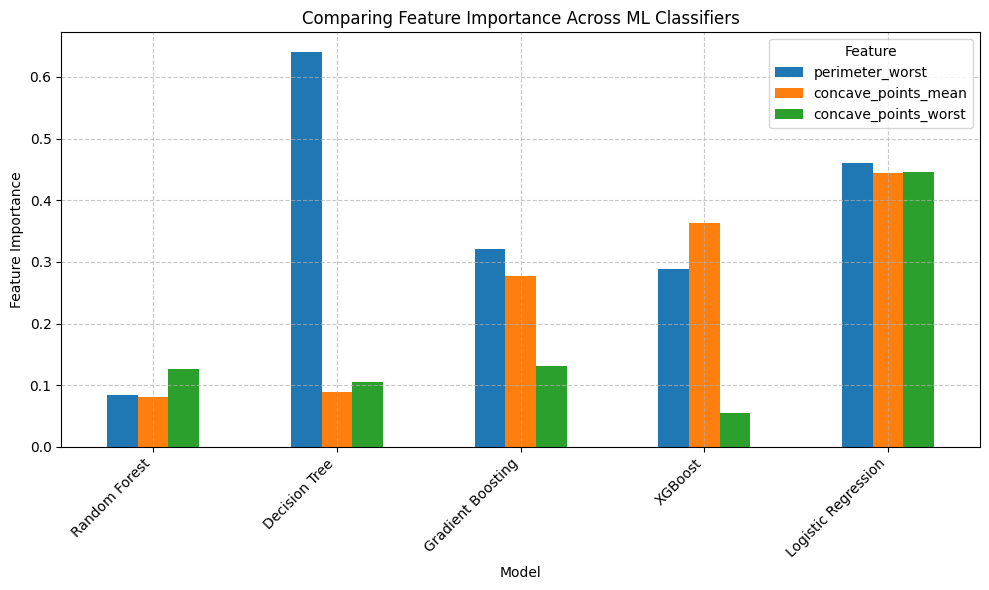

In [ ]:
#drops average importance column; transposition -> rows become models and columns become top 3 features
data_to_plot = top_3_features.drop(columns='Average Importance').T

#internal colour configuration
matplotlib_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

colours = matplotlib_colors[:len(data_to_plot.columns)]

#plots transposed dataframe as bar chart
ax = data_to_plot.plot(kind='bar', figsize=(10, 6), color=colours)
plt.title('Comparing Feature Importance Across ML Classifiers')
plt.xlabel('Model')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Feature', loc='best')
plt.tight_layout()
plt.show()
